# Erweiterung des Credal-Set-Diversity-Vektors um Diskurskohärenz

Bisher 3D-Vektor:

$$\mathbf{v}_p = (D_{\text{sem}}, D_{\text{lex}}, D_{\text{syn}})$$

Erste Erweiterung: **$D_{\text{disc}}$ — Discourse Diversity**, basierend auf dem Entity-Grid-Modell (Barzilay & Lapata, 2008).

$$\mathbf{v}_p^{\text{ext}} = (D_{\text{sem}}, D_{\text{lex}}, D_{\text{syn}}, \underbrace{D_{\text{disc}}}_{\text{neu}})$$

### Daten
- [`human_drift`](https://github.com/EstebanGarces/human_drift) — 100 Prompts × 10 Stories × 5 Sources
- $D_{\text{sem}}, D_{\text{lex}}, D_{\text{syn}}$: vorberechnet aus dem Repository

In [50]:
import numpy as np
import json, re, os, time, warnings
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
from collections import Counter
from scipy.spatial.distance import cdist
from scipy.spatial import ConvexHull
from scipy.stats import entropy, mannwhitneyu
from sklearn.decomposition import PCA
from matplotlib.patches import Polygon
warnings.filterwarnings('ignore')
np.random.seed(42)

# spaCy NER laden (Fallback auf Kapitalisierungs-Heuristik)
USE_SPACY = False
try:
    import spacy
    nlp = spacy.load('en_core_web_sm')
    USE_SPACY = True
    print('✓ spaCy NER geladen (en_core_web_sm)')
except Exception:
    print('⚠ spaCy nicht verfügbar → Kapitalisierungs-Heuristik als Fallback')

# Konfiguration
N_PROMPTS = 100
SOURCES = ['human', 'llama', 'mistral', 'qwen', 'gemma']
REPO_DIR = Path('../human_drift')

SOURCE_COLORS = {
    'human': '#1565C0', 'llama': '#E65100',
    'mistral': '#6A1B9A', 'qwen': '#2E7D32', 'gemma': '#C62828',
}

✓ spaCy NER geladen (en_core_web_sm)


## 1. Daten laden

In [ ]:
# ============================================================
# 1. DATEN + VORBERECHNETE 3D-METRIKEN
# ============================================================

# Storytelling-Texte aus dem Repo laden
texts = {}
for source in SOURCES:
    fp = REPO_DIR / 'clean_generations' / f'{source}_storytelling_clean.json'
    with open(fp) as f:
        raw = json.load(f)
    prompts = list(raw.keys())[:N_PROMPTS]
    texts[source] = {i: raw[p] for i, p in enumerate(prompts)}

# Vorberechnete 3D-Metriken (per-Prompt-Mittelwerte aus dem Repo)
with open(REPO_DIR / 'drift_analysis' / 'per_input_distances.json') as f:
    per_input_3d = json.load(f)

# In Arrays packen: baseline_3d[source] = (100, 3)
baseline_3d = {}
for source in SOURCES:
    sem = per_input_3d[source]['storytelling']['semantic']
    lex = per_input_3d[source]['storytelling']['lexical']
    syn = per_input_3d[source]['storytelling']['syntactic']
    baseline_3d[source] = np.column_stack([sem, lex, syn])

# Statistiken
total = sum(len(texts[s][p]) for s in SOURCES for p in texts[s])
print(f'{total:,} Texte geladen (100 Prompts × 5 Sources)')
for source in SOURCES:
    means = baseline_3d[source].mean(axis=0)
    print(f'  {source:8s}: Sem={means[0]:.3f}, Lex={means[1]:.3f}, Syn={means[2]:.3f}')

4,994 Texte geladen (100 Prompts × 5 Sources)
  human   : Sem=0.666, Lex=0.985, Syn=0.805
  llama   : Sem=0.352, Lex=0.937, Syn=0.692
  mistral : Sem=0.287, Lex=0.936, Syn=0.671
  qwen    : Sem=0.345, Lex=0.959, Syn=0.704
  gemma   : Sem=0.343, Lex=0.958, Syn=0.685


## 2. $D_{\text{disc}}$ — Discourse Diversity

**Entity-Grid-Modell** (Barzilay & Lapata, 2008): Modelliert Textkohärenz über das Verhalten von Entitäten über Satzgrenzen hinweg.

Für jeden Text wird eine Matrix erstellt:

| | Entity A | Entity B | Entity C |
|---|---|---|---|
| Satz 1 | 1 | 0 | 1 |
| Satz 2 | 1 | 1 | 0 |
| Satz 3 | 0 | 1 | 0 |

4 möglichen Transitionen `{(0,0), (0,1), (1,0), (1,1)}` -> **Diskurs-Fingerabdruck** eines Textes

$D_{\text{disc}}$ = mittlere paarweise Jensen-Shannon-Divergenz zwischen diesen Fingerabdrücken

- **spaCy Named Entity Recognition** (PERSON, ORG, GPE, LOC) für Entity-Extraktion
- Fallback: **Kapitalisierungs-Heuristik**, die großgeschriebene Wörter (außer Satzanfängen und Funktionswörtern) als Entities erkennt und Multi-Word-Entities gruppiert.

In [53]:
# ============================================================
# 2. D_disc IMPLEMENTIERUNG
# ============================================================

def sent_tokenize(text):
    """Robuster Satz-Tokenizer"""
    sents = re.split(r'(?<=[.!?])\s+', text.strip())

    return [s.strip() for s in sents if len(s.strip()) > 5]


# Kapitalisierungs-Heuristik als Fallback
_COMMON_UPPER = {'the', 'a', 'an', 'i', 'in', 'on', 'at', 'to', 'for',
    'but', 'and', 'or', 'it', 'he', 'she', 'we', 'they', 'my', 'his', 'her',
    'so', 'if', 'as', 'no', 'not', 'all', 'one', 'two', 'first', 'last',
    'just', 'then', 'now', 'here', 'there', 'when', 'where', 'how', 'what',
    'who', 'why', 'this', 'that', 'with', 'from', 'been', 'have', 'has',
    'was', 'were', 'are', 'had', 'would', 'could', 'should', 'will',
    'can', 'may', 'might', 'shall', 'must', 'did', 'does', 'do',
    'said', 'went', 'came', 'back', 'up', 'out', 'off', 'down',
    'over', 'after', 'before', 'still', 'even', 'also', 'very',
    'well', 'right', 'through', 'into', 'about', 'than', 'them',
    'each', 'which', 'their', 'some', 'our', 'your', 'its',
}


def extract_entities_spacy(sentence):
    """Extrahiere Named Entities mit spaCy NER"""
    doc = nlp(sentence)
    valid_labels = {'PERSON', 'ORG', 'GPE', 'LOC', 'PRODUCT', 'EVENT', 'WORK_OF_ART'}

    return set(ent.text.lower() for ent in doc.ents if ent.label_ in valid_labels)


def extract_entities_heuristic(sentence, is_first_sent=False):
    """Extrahiere Entities via Kapitalisierungs-Heuristik"""
    words = sentence.split()
    entities = set()
    i = 0

    while i < len(words):
        word = re.sub(r'[^a-zA-Z]', '', words[i])

        if not word:
            i += 1
            continue

        if word[0].isupper() and len(word) > 1 and word.lower() not in _COMMON_UPPER:
            parts = [word]
            j = i + 1

            while j < len(words):
                nw = re.sub(r'[^a-zA-Z]', '', words[j])

                if nw and nw[0].isupper() and len(nw) > 1 and nw.lower() not in _COMMON_UPPER:
                    parts.append(nw)
                    j += 1
                else:
                    break

            entities.add(' '.join(parts).lower())
            i = j

        else:
            i += 1

    return entities


def extract_entities(sentence):
    """Entity-Extraktion: spaCy NER oder Kapitalisierungs-Fallback"""
    if USE_SPACY:
        return extract_entities_spacy(sentence)
    
    return extract_entities_heuristic(sentence)


def entity_grid_transitions(text):
    """Berechne Entity-Grid-Transitionen für einen Text"""
    sents = sent_tokenize(text)

    if len(sents) < 2:
        return Counter(), [], []
    
    # Entities pro Satz extrahieren
    sent_entities = [extract_entities(s) for s in sents]
    all_entities = set().union(*sent_entities)
    
    if not all_entities:
        return Counter(), sent_entities, list(all_entities)
    
    # Transitionen zählen
    transitions = Counter()
    for entity in all_entities:
        presence = [1 if entity in se else 0 for se in sent_entities]
        for k in range(len(presence) - 1):
            transitions[(presence[k], presence[k+1])] += 1
    
    return transitions, sent_entities, list(all_entities)


def jsd(p, q):
    """Jensen-Shannon Divergenz"""
    p = np.asarray(p, dtype=float) + 1e-10
    q = np.asarray(q, dtype=float) + 1e-10
    p /= p.sum(); q /= q.sum()
    m = 0.5 * (p + q)

    return 0.5 * (entropy(p, m) + entropy(q, m))


def discourse_diversity(texts_list):
    """Discourse Diversity: mittlere paarweise JSD der Entity-Grid-Profile"""
    trans_types = [(0,0), (0,1), (1,0), (1,1)]
    profiles = []

    for t in texts_list:
        trans, _, _ = entity_grid_transitions(t)
        total = sum(trans.values()) or 1
        profiles.append(np.array([trans[tt] / total for tt in trans_types]))

    profiles = np.array(profiles)
    pairs = list(combinations(range(len(texts_list)), 2))
    
    return np.mean([jsd(profiles[i], profiles[j]) for i, j in pairs])


print('D_disc implementiert.')

D_disc implementiert.


### Beispiel Entity-Grid für einen Text

Beispieltext: Prompt 0, Story 0
Text: 15 Sätze, 11 Entities
Entities: ['leonardo', 'imma', 'oscar', 'kanye west', 'hollywood', 'adam sandler', 'paul blart', "`` fart master v''", 'kanye', 'afterward dicaprio'] ...

Transitionen: {(0, 0): 127, (0, 1): 13, (1, 0): 14}

Profil (normalisiert):
  absent→absent       :  82.5% █████████████████████████████████████████
  absent→present      :   8.4% ████
  present→absent      :   9.1% ████
  present→present     :   0.0% 


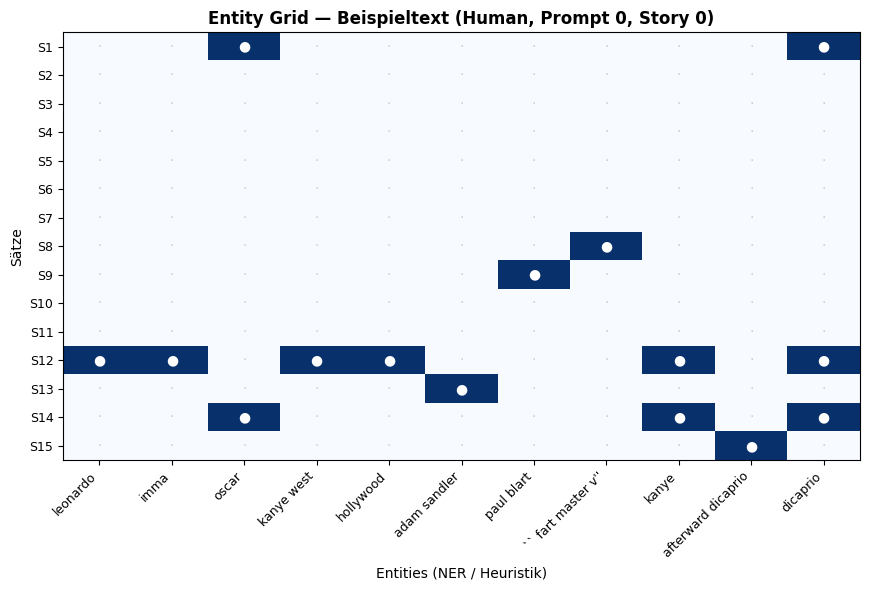

In [59]:
# ============================================================
# BEISPIEL: Entity-Grid-Visualisierung
# ============================================================

# Beispiel Text
example_story = texts['human'][0][1]
example_prompt_idx, example_story_idx = 0, 0
print(f'Beispieltext: Prompt {example_prompt_idx}, Story {example_story_idx}')

# Entity-Grid-Transitionen berechnen
trans, sent_ents, all_ents = entity_grid_transitions(example_story)
sents = sent_tokenize(example_story)

print(f'Text: {len(sents)} Sätze, {len(all_ents)} Entities')
print(f'Entities: {all_ents[:10]}' + (' ...' if len(all_ents) > 10 else ''))
print(f'\nTransitionen: {dict(trans)}')
total = sum(trans.values())
print(f'\nProfil (normalisiert):')
for tt in [(0,0), (0,1), (1,0), (1,1)]:
    pct = trans[tt] / total * 100 if total else 0
    label = {(0,0): 'absent→absent', (0,1): 'absent→present',
             (1,0): 'present→absent', (1,1): 'present→present'}[tt]
    bar = '█' * int(pct / 2)
    print(f'  {label:20s}: {pct:5.1f}% {bar}')

# Entity-Grid als Heatmap
if all_ents:
    show_ents = all_ents[:15]  # max 15 Entities
    show_sents = min(len(sents), 20)
    grid = np.zeros((show_sents, len(show_ents)))
    for i in range(show_sents):
        for j, ent in enumerate(show_ents):
            grid[i, j] = 1 if ent in sent_ents[i] else 0

    fig, ax = plt.subplots(figsize=(max(8, len(show_ents)*0.8), show_sents*0.4))
    ax.imshow(grid, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(show_ents)))
    ax.set_xticklabels(show_ents, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(show_sents))
    ax.set_yticklabels([f'S{i+1}' for i in range(show_sents)], fontsize=9)
    ax.set_xlabel('Entities (NER / Heuristik)')
    ax.set_ylabel('Sätze')
    ax.set_title(
        f'Entity Grid — Beispieltext (Human, Prompt {example_prompt_idx}, Story {example_story_idx})',
        fontsize=12, fontweight='bold')
    for i in range(show_sents):
        for j in range(len(show_ents)):
            ax.text(j, i, '●' if grid[i,j] else '·', ha='center', va='center',
                   fontsize=10, color='white' if grid[i,j] else '#CCCCCC')
    plt.tight_layout()
    plt.savefig('example_entity_grid.png', dpi=150, bbox_inches='tight')
    plt.show()

## 3. Berechnung über alle Prompts und Sources

In [60]:
# ============================================================
# 3. D_disc FÜR ALLE PROMPTS BERECHNEN
# ============================================================

disc_scores = {}  # disc_scores[source] = array(100,)

t0 = time.time()

for source in SOURCES:
    scores = []
    for p in range(N_PROMPTS):
        d = discourse_diversity(texts[source][p])
        scores.append(d)
        if (p + 1) % 50 == 0:
            print(f'  {source:8s}: {p+1}/{N_PROMPTS} ({time.time()-t0:.0f}s)')
    disc_scores[source] = np.array(scores)

print(f'\nFertig in {time.time()-t0:.0f}s')

# 4D-Vektor zusammenbauen: baseline_3d + D_disc
results_4d = {}
for source in SOURCES:
    results_4d[source] = np.column_stack([
        baseline_3d[source],
        disc_scores[source]
    ])

print(f'\n4D-Vektor: (Sem, Lex, Syn, Disc)')
METRIC_NAMES = ['Sem', 'Lex', 'Syn', 'Disc']
print(f'{"":<10}', end='')


for s in SOURCES: print(f'{s:>14}', end='')
print()
print('-' * 80)
for i, name in enumerate(METRIC_NAMES):
    print(f'{name:<10}', end='')
    for source in SOURCES:
        m = results_4d[source][:, i].mean()
        s = results_4d[source][:, i].std()
        print(f'{m:>8.4f}±{s:<5.3f}', end='')
    print()

  human   : 50/100 (62s)
  human   : 100/100 (116s)
  llama   : 50/100 (161s)
  llama   : 100/100 (205s)
  mistral : 50/100 (251s)
  mistral : 100/100 (295s)
  qwen    : 50/100 (330s)
  qwen    : 100/100 (365s)
  gemma   : 50/100 (397s)
  gemma   : 100/100 (430s)

Fertig in 430s

4D-Vektor: (Sem, Lex, Syn, Disc)
                   human         llama       mistral          qwen         gemma
--------------------------------------------------------------------------------
Sem         0.6664±0.070  0.3519±0.096  0.2866±0.094  0.3455±0.087  0.3432±0.084
Lex         0.9850±0.004  0.9365±0.018  0.9363±0.020  0.9592±0.013  0.9582±0.012
Syn         0.8046±0.016  0.6917±0.032  0.6713±0.024  0.7042±0.026  0.6847±0.026
Disc        0.0627±0.043  0.0581±0.043  0.0519±0.041  0.0559±0.042  0.0665±0.050


## 4. Ergebnisse: Ist $D_{\text{disc}}$ informativ?

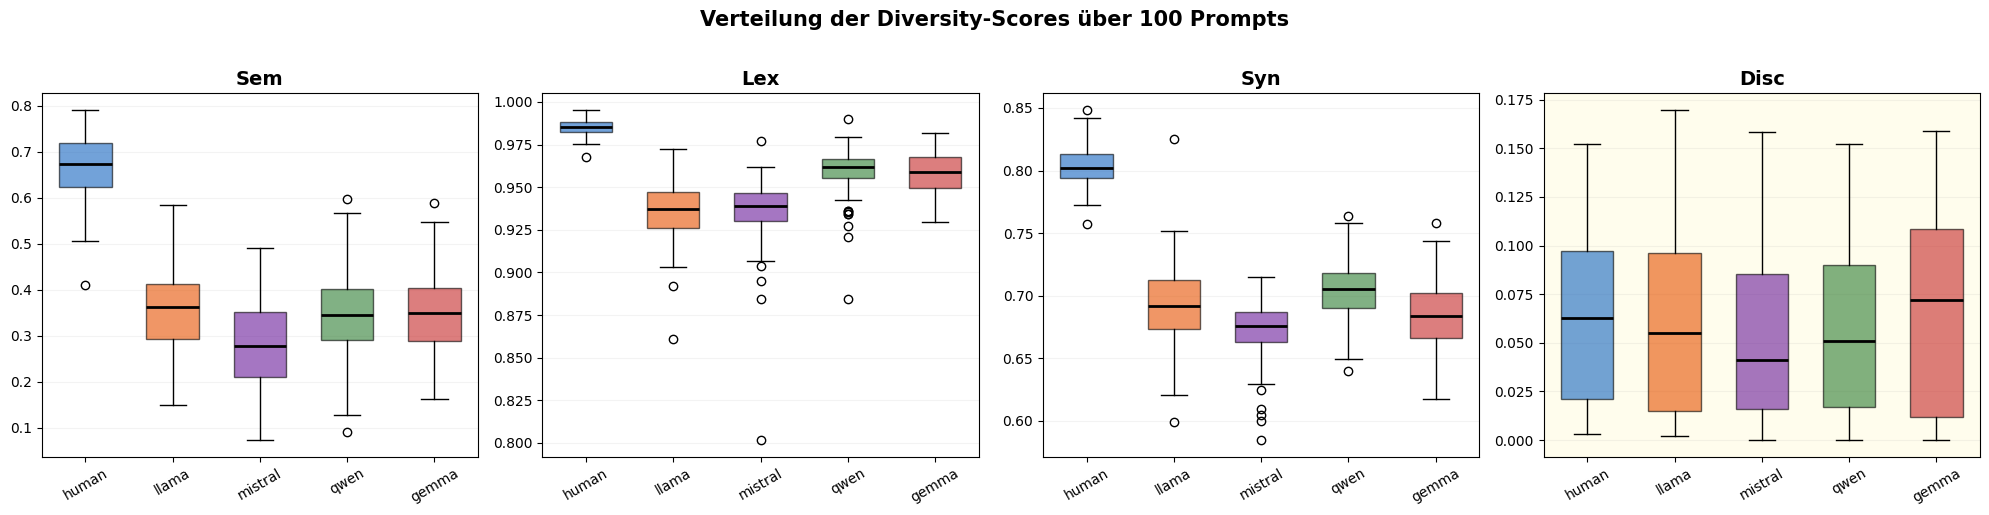

In [67]:
# ============================================================
# 4a. BOXPLOT: D_disc über 5 Sources
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, (name, ax) in enumerate(zip(METRIC_NAMES, axes)):
    data = [results_4d[s][:, i] for s in SOURCES]
    bp = ax.boxplot(data, labels=SOURCES, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2), widths=0.6)
    for patch, source in zip(bp['boxes'], SOURCES):
        patch.set_facecolor(SOURCE_COLORS[source])
        patch.set_alpha(0.6)
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.15, axis='y')
    # Highlight D_disc
    if name == 'Disc':
        ax.patch.set_facecolor('#FFF9C4')
        ax.patch.set_alpha(0.3)

fig.suptitle('Verteilung der Diversity-Scores über 100 Prompts',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('diversity_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

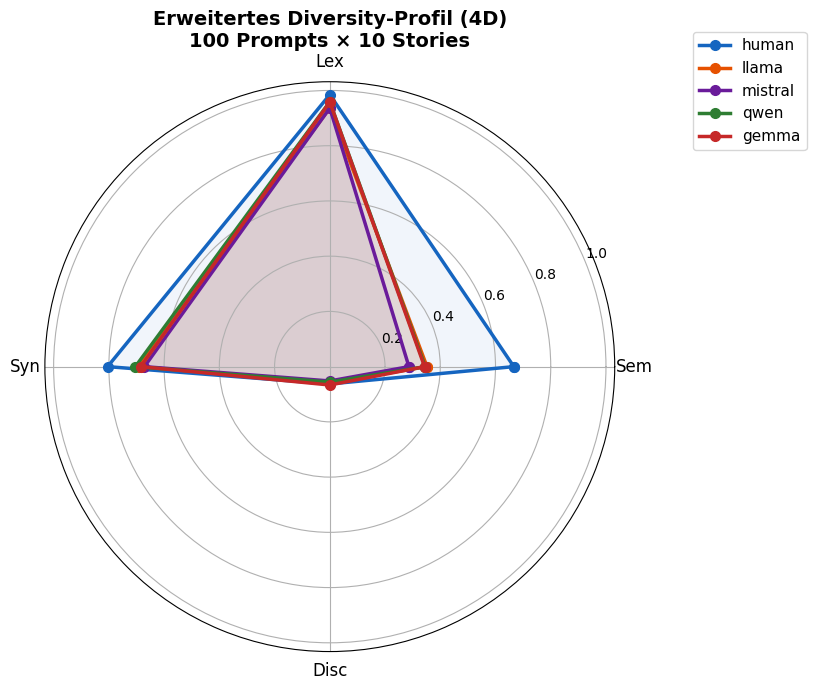

In [68]:
# ============================================================
# 4b. RADAR CHART: 4D-Profil
# ============================================================

angles = np.linspace(0, 2 * np.pi, 4, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 7), subplot_kw=dict(polar=True))

for source in SOURCES:
    means = results_4d[source].mean(axis=0)
    values = means.tolist() + [means[0]]
    ax.plot(angles, values, 'o-', color=SOURCE_COLORS[source],
            linewidth=2.5, label=source, markersize=7)
    ax.fill(angles, values, alpha=0.06, color=SOURCE_COLORS[source])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(METRIC_NAMES, fontsize=12)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)
ax.set_title('Erweitertes Diversity-Profil (4D)\n100 Prompts × 10 Stories',
             fontsize=14, fontweight='bold', pad=25)
plt.tight_layout()
plt.savefig('diversity_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

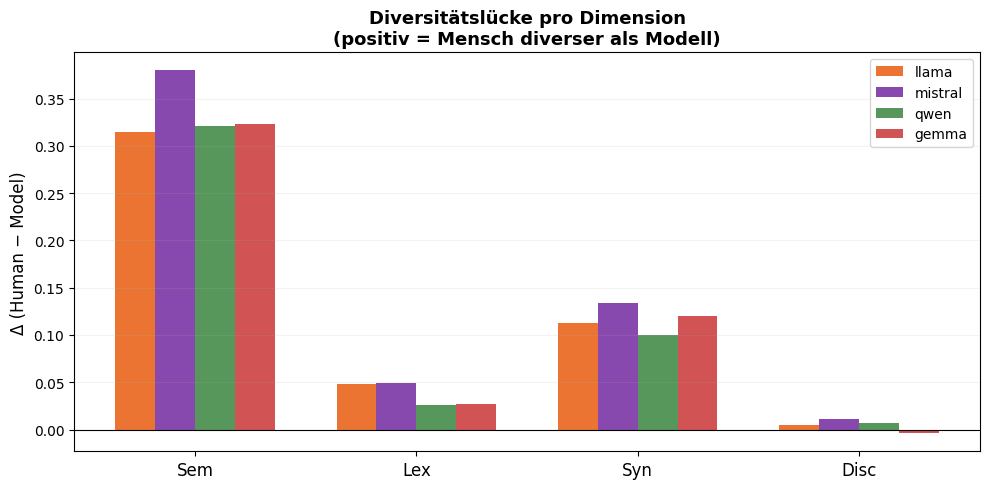

In [66]:
# ============================================================
# 4c. DIVERSITÄTSLÜCKE: Human - Modell pro Dimension
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(4)
width = 0.18
for j, source in enumerate(SOURCES[1:]):
    deltas = results_4d['human'].mean(axis=0) - results_4d[source].mean(axis=0)
    ax.bar(x + j*width, deltas, width, label=source,
           color=SOURCE_COLORS[source], alpha=0.8)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(METRIC_NAMES, fontsize=12)
ax.set_ylabel('Δ (Human − Model)', fontsize=12)
ax.set_title('Diversitätslücke pro Dimension\n(positiv = Mensch diverser als Modell)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.15, axis='y')

plt.tight_layout()
plt.savefig('diversity_gap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Korrelation: Ist $D_{\text{disc}}$ orthogonal zu den bestehenden Metriken?

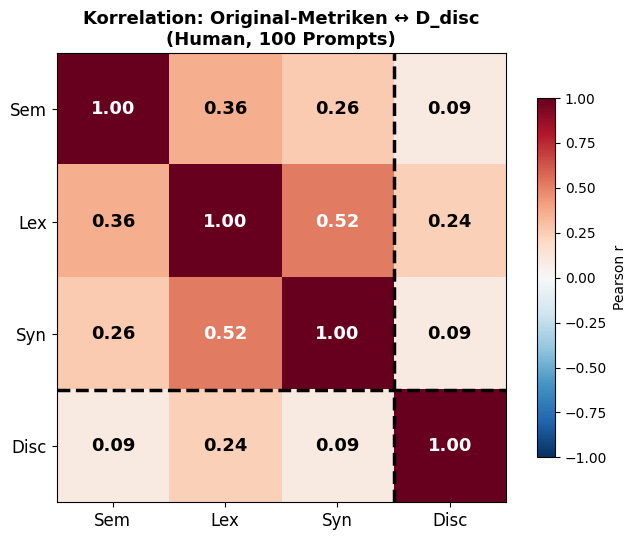

Korrelationen mit D_disc:
  Sem–Disc: r = +0.091 (schwach)
  Lex–Disc: r = +0.241 (schwach)
  Syn–Disc: r = +0.086 (schwach)


In [71]:
# ============================================================
# 5. KORRELATIONSANALYSE
# ============================================================

human_4d = results_4d['human']
corr = np.corrcoef(human_4d.T)

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(METRIC_NAMES, fontsize=12)
ax.set_yticklabels(METRIC_NAMES, fontsize=12)
for i in range(4):
    for j in range(4):
        c = 'white' if abs(corr[i,j]) > 0.5 else 'black'
        ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center',
                fontsize=13, color=c, fontweight='bold')
ax.axhline(2.5, color='black', linewidth=2.5, linestyle='--')
ax.axvline(2.5, color='black', linewidth=2.5, linestyle='--')
ax.set_title('Korrelation: Original-Metriken ↔ D_disc\n(Human, 100 Prompts)',
             fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Korrelationen mit D_disc:')
for i, name in enumerate(METRIC_NAMES[:3]):
    r = corr[i, 3]
    strength = 'stark' if abs(r) > 0.5 else 'moderat' if abs(r) > 0.3 else 'schwach'
    print(f'  {name}–Disc: r = {r:+.3f} ({strength})')

## 6. PCA: Was bringt die vierte Dimension?

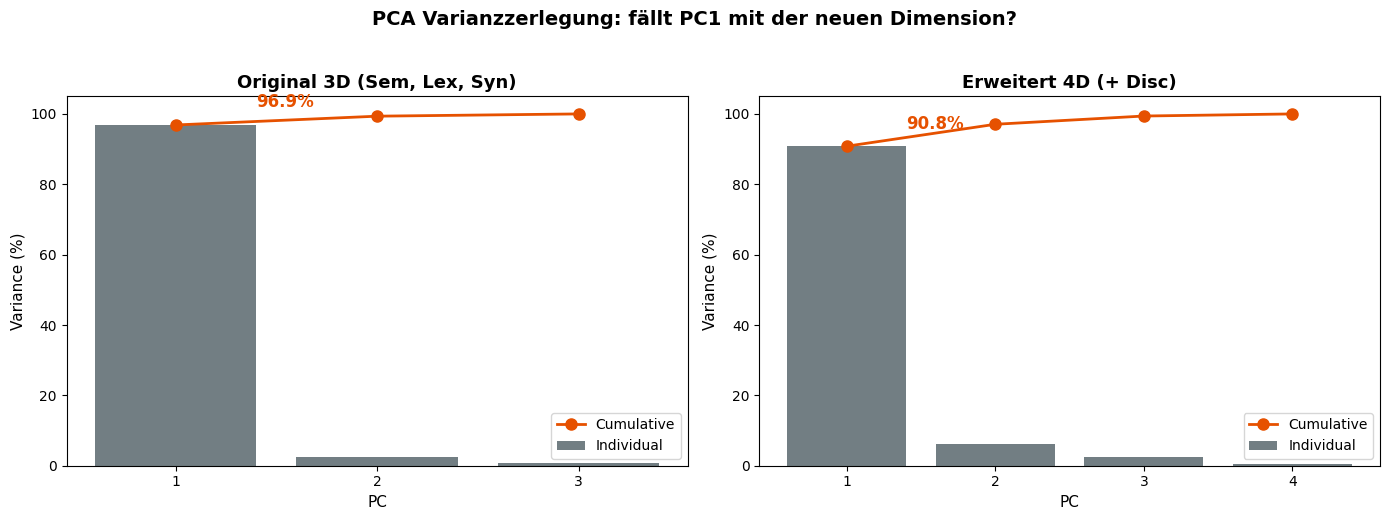

PC1 Varianzanteil:
  3D (Paper):    96.9%
  4D (+ Disc):   90.8%
  Paper (Ref):   85.8%

→ Abfall: 6.0% = D_disc bringt orthogonale Information


In [72]:
# ============================================================
# 6. PCA: 3D vs 4D
# ============================================================

all_4d = np.vstack([results_4d[s] for s in SOURCES])
all_3d = all_4d[:, :3]

pca_3d = PCA().fit(all_3d)
pca_4d = PCA().fit(all_4d)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianzzerlegung visualisieren
for ax, pca_obj, title, n_dim in [
    (axes[0], pca_3d, 'Original 3D (Sem, Lex, Syn)', 3),
    (axes[1], pca_4d, 'Erweitert 4D (+ Disc)', 4),
]:
    var = pca_obj.explained_variance_ratio_ * 100
    cum = np.cumsum(var)
    ax.bar(range(1, n_dim+1), var, color='#37474F', alpha=0.7, label='Individual')
    ax.plot(range(1, n_dim+1), cum, 'o-', color='#E65100', linewidth=2,
            markersize=8, label='Cumulative')
    ax.set_xlabel('PC', fontsize=11); ax.set_ylabel('Variance (%)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(range(1, n_dim+1))
    ax.legend(fontsize=10)
    ax.annotate(f'{var[0]:.1f}%', xy=(1, var[0]), xytext=(1.4, var[0]+5),
                fontsize=12, fontweight='bold', color='#E65100')

plt.suptitle('PCA Varianzzerlegung: fällt PC1 mit der neuen Dimension?',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'PC1 Varianzanteil:')
print(f'  3D (Paper):    {pca_3d.explained_variance_ratio_[0]:.1%}')
print(f'  4D (+ Disc):   {pca_4d.explained_variance_ratio_[0]:.1%}')
print(f'  Paper (Ref):   85.8%')
print(f'\n→ Abfall: {pca_3d.explained_variance_ratio_[0] - pca_4d.explained_variance_ratio_[0]:.1%} '
      f'= D_disc bringt orthogonale Information')

## 7. Credal Sets: 3D vs 4D

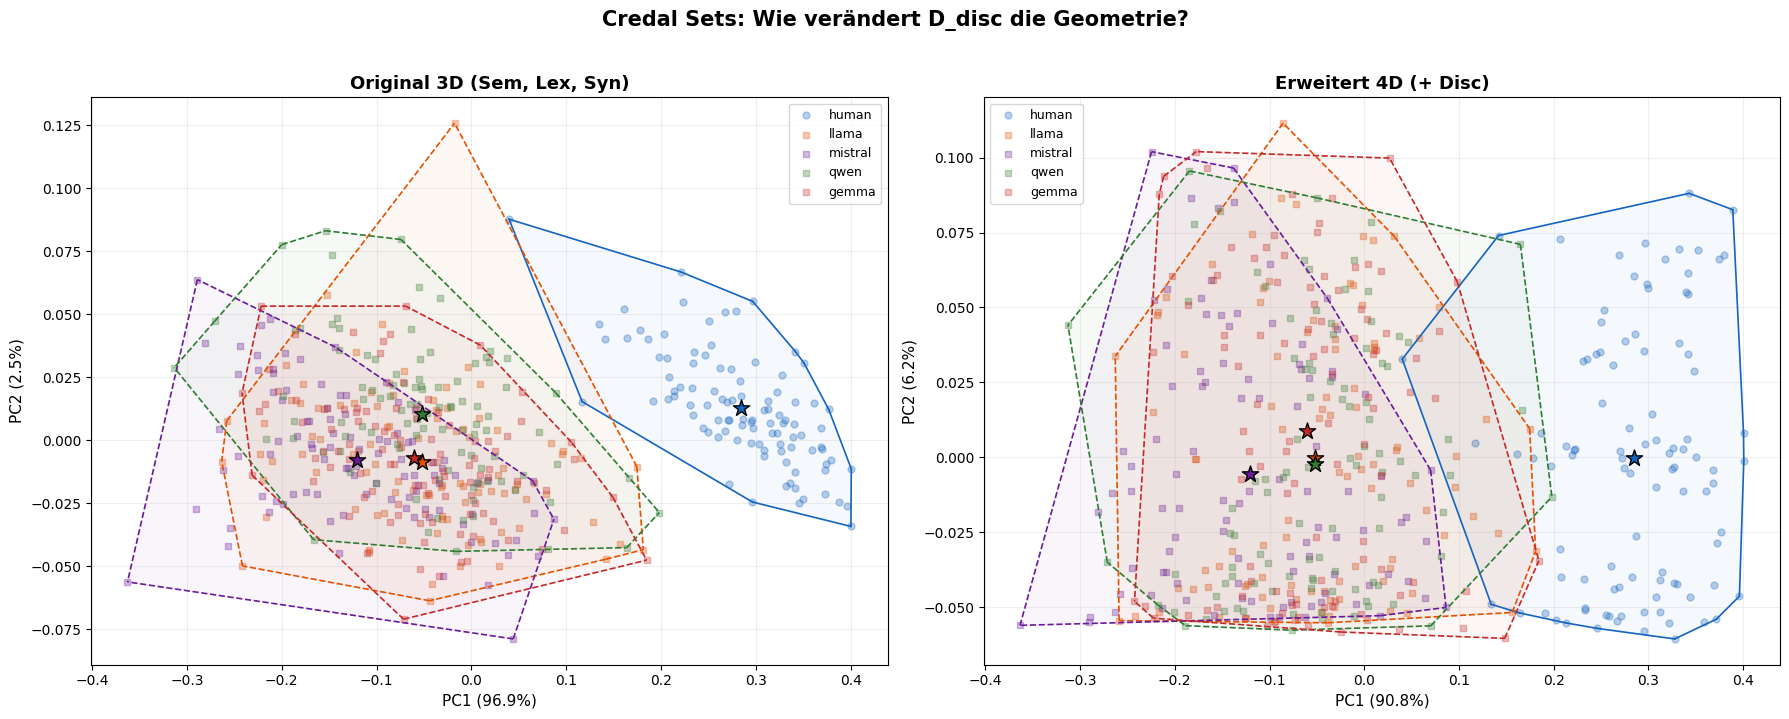

In [39]:
# ============================================================
# 7. CREDAL SETS (side-by-side: 3D vs 4D)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, data_dict, title in [
    (axes[0], {s: results_4d[s][:, :3] for s in SOURCES}, 'Original 3D (Sem, Lex, Syn)'),
    (axes[1], results_4d, 'Erweitert 4D (+ Disc)'),
]:
    all_data = np.vstack([data_dict[s] for s in SOURCES])
    pca_2d = PCA(n_components=2)
    all_pca = pca_2d.fit_transform(all_data)
    
    for i, source in enumerate(SOURCES):
        n = len(data_dict[source])
        pts = all_pca[i*n:(i+1)*n]
        marker = 'o' if source == 'human' else 's'
        ax.scatter(pts[:, 0], pts[:, 1], c=SOURCE_COLORS[source], alpha=0.3,
                  s=25, marker=marker, label=source)
        centroid = pts.mean(axis=0)
        ax.scatter(*centroid, c=SOURCE_COLORS[source], s=150, marker='*',
                  edgecolors='black', linewidth=1, zorder=5)
        try:
            hull = ConvexHull(pts)
            for simplex in hull.simplices:
                ls = '-' if source == 'human' else '--'
                ax.plot(pts[simplex, 0], pts[simplex, 1],
                        color=SOURCE_COLORS[source], linewidth=1.2, linestyle=ls)
            poly = Polygon(pts[hull.vertices], alpha=0.04, color=SOURCE_COLORS[source])
            ax.add_patch(poly)
        except Exception:
            pass
    
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

plt.suptitle('Credal Sets: Wie verändert D_disc die Geometrie?',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [74]:
# ============================================================
# 7b. OVERLAP-KOEFFIZIENTEN: 3D vs 4D
# ============================================================

def overlap_coefficient(points_a, points_b):
    dists_ab = cdist(points_a, points_b)
    dists_ba = cdist(points_b, points_a)

    all_pts = np.vstack([points_a, points_b])
    all_d = cdist(all_pts, all_pts)
    np.fill_diagonal(all_d, np.inf)

    theta = 0.5 * np.mean(all_d.min(axis=1))
    
    a_near = np.mean(dists_ab.min(axis=1) < theta)
    b_near = np.mean(dists_ba.min(axis=1) < theta)

    return 0.5 * (a_near + b_near)


print('Kalibrierung: Overlap Human ↔ Modell')
print(f'{"Modell":<10} {"3D (orig)":>10} {"4D (+Disc)":>12} {"Δ":>8}')
print('-' * 44)

h = results_4d['human']
for source in SOURCES[1:]:
    m = results_4d[source]
    ov_3d = overlap_coefficient(h[:, :3], m[:, :3])
    ov_4d = overlap_coefficient(h, m)
    delta = ov_4d - ov_3d
    print(f'{source:<10} {ov_3d:>10.3f} {ov_4d:>12.3f} {delta:>+8.3f}')

Kalibrierung: Overlap Human ↔ Modell
Modell      3D (orig)   4D (+Disc)        Δ
--------------------------------------------
llama           0.000        0.000   +0.000
mistral         0.000        0.000   +0.000
qwen            0.000        0.000   +0.000
gemma           0.000        0.000   +0.000


## 8. Credal Sets für $D_{\text{disc}}$

1. Pro Prompt: alle $\binom{10}{2} = 45$ paarweisen JSD-Distanzen zwischen den Entity-Grid-Profilen
2. **Gepoolter Rang-Transform** über alle Sources
3. **K = 15 Bins** auf [0,1] + Laplace-Glättung (α = 1) -> Simplex-Punkt auf $\Delta^{14}$
4. **Credal Set** = konvexe Hülle aller 100 Simplex-Punkte pro Source
5. **PCA** → 2D-Projektion

In [75]:
# ============================================================
# 8a. PAARWEISE JSD-DISTANZEN + SIMPLEX-PUNKTE
# ============================================================

K_BINS_DISC = 15
ALPHA_SMOOTH = 1.0
BIN_EDGES = np.linspace(0, 1, K_BINS_DISC + 1)
TRANS_TYPES_4 = [(0,0), (0,1), (1,0), (1,1)]

def pairwise_jsd_disc(texts_list):
    """45 paarweise JSD-Distanzen zwischen Entity-Grid-Profilen für einen Prompt"""
    profiles = []

    for t in texts_list:
        trans, _, _ = entity_grid_transitions(t)
        total = sum(trans.values()) or 1
        profiles.append(np.array([trans[tt] / total for tt in TRANS_TYPES_4]))

    pairs = list(combinations(range(len(texts_list)), 2))

    return np.array([jsd(profiles[i], profiles[j]) for i, j in pairs])

# Paarweise Distanzen für alle Prompts × Sources
raw_disc_dists = {}  # raw_disc_dists[source] = (100, 45)
t0 = time.time()

for source in SOURCES:
    raw_disc_dists[source] = [
        pairwise_jsd_disc(texts[source][p]) for p in range(N_PROMPTS)
    ]

print(f'Distanzen berechnet in {time.time()-t0:.0f}s')

# Gepoolter Rang-Transform (alle Sources zusammen)
all_raw = np.concatenate([np.concatenate(raw_disc_dists[s]) for s in SOURCES])
sorted_ref = np.sort(all_raw)

def rank_transform(values):
    return np.searchsorted(sorted_ref, values, side='right') / len(sorted_ref)

def dist_to_simplex(distances):
    ranked = rank_transform(distances)
    counts, _ = np.histogram(ranked, bins=BIN_EDGES)
    smoothed = counts + ALPHA_SMOOTH
    
    return smoothed / smoothed.sum()

# Simplex-Punkte: disc_simplex[source] = (100, 15)
disc_simplex = {
    s: np.array([dist_to_simplex(raw_disc_dists[s][p]) for p in range(N_PROMPTS)])
    for s in SOURCES
}

print(f'Simplex-Punkte: {list(disc_simplex.values())[0].shape}')
print(f'Mittlere Distanz pro Source:')
for s in SOURCES:
    mean_d = np.concatenate(raw_disc_dists[s]).mean()
    print(f'  {s:8s}: {mean_d:.4f}')


Distanzen berechnet in 428s
Simplex-Punkte: (100, 15)
Mittlere Distanz pro Source:
  human   : 0.0627
  llama   : 0.0581
  mistral : 0.0519
  qwen    : 0.0562
  gemma   : 0.0665


PCA: PC1=41.2%, PC2=16.3%


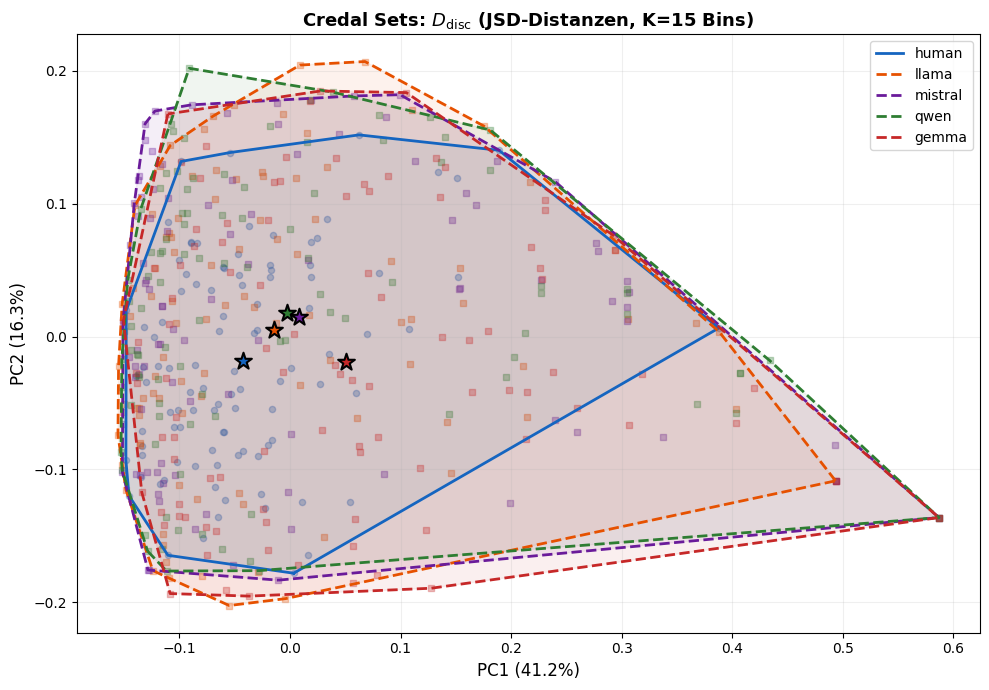

In [76]:
# =====================================
# 8b. CREDAL SETS: PCA + KONVEXE HÜLLE 
# =====================================

# PCA auf alle Simplex-Punkte (über alle Sources) für 2D-Visualisierung
all_simplex_pts = np.vstack([disc_simplex[s] for s in SOURCES])
pca_disc = PCA(n_components=2)
pca_disc.fit(all_simplex_pts)
disc_2d = {s: pca_disc.transform(disc_simplex[s]) for s in SOURCES}

print(f'PCA: PC1={pca_disc.explained_variance_ratio_[0]*100:.1f}%, '
      f'PC2={pca_disc.explained_variance_ratio_[1]*100:.1f}%')

fig, ax = plt.subplots(figsize=(10, 7))

for source in SOURCES:
    pts = disc_2d[source]
    ls = '-' if source == 'human' else '--'
    marker = 'o' if source == 'human' else 's'
    ax.scatter(pts[:, 0], pts[:, 1], c=SOURCE_COLORS[source],
               alpha=0.3, s=20, marker=marker)
    centroid = pts.mean(axis=0)
    ax.scatter(*centroid, c=SOURCE_COLORS[source], s=160, marker='*',
               edgecolors='black', linewidth=1.5, zorder=6)
    try:
        hull = ConvexHull(pts)
        hull_idx = np.append(hull.vertices, hull.vertices[0])
        ax.fill(pts[hull.vertices, 0], pts[hull.vertices, 1],
                alpha=0.07, color=SOURCE_COLORS[source])
        ax.plot(pts[hull_idx, 0], pts[hull_idx, 1],
                color=SOURCE_COLORS[source], linewidth=2,
                linestyle=ls, label=source)
    except Exception:
        pass

ax.set_xlabel(f'PC1 ({pca_disc.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_disc.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title(
    'Credal Sets: $D_{\\text{disc}}$ (JSD-Distanzen, K=15 Bins)',
    #'Konvexe Hülle der Simplex-Punkte — Human: durchgezogen, Modelle: gestrichelt',
    fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


In [77]:
# ============================================================
# ERGEBNISSE SPEICHERN
# ============================================================

output = {
    'metric_names': METRIC_NAMES,
    'sources': SOURCES,
    'n_prompts': N_PROMPTS,
    'results_4d': {s: results_4d[s].tolist() for s in SOURCES},
    'correlation_matrix': corr.tolist(),
    'pca_3d_pc1': float(pca_3d.explained_variance_ratio_[0]),
    'pca_4d_pc1': float(pca_4d.explained_variance_ratio_[0]),
}

with open('disc_diversity_results.json', 'w') as f:
    json.dump(output, f, indent=2)

print('Ergebnisse gespeichert: disc_diversity_results.json')

Ergebnisse gespeichert: disc_diversity_results.json
